# Spaceship Titanic — Modeling & Evaluation

**Notebook 03 of 3** — Train classifiers, evaluate performance, explain predictions, test business hypotheses, and submit to Kaggle.

## Goals

- Train three classifiers: Logistic Regression (baseline), Random Forest, XGBoost
- Evaluate using accuracy, AUC-ROC, precision, recall, F1, and confusion matrix
- Tune XGBoost with Bayesian optimization
- Explain predictions with SHAP
- Test business hypotheses with chi-squared tests
- Generate Kaggle submission

## Notebook Structure

1. Setup and Data Loading
2. Baseline — Logistic Regression
3. Random Forest
4. XGBoost
5. Hyperparameter Tuning with Bayesian Optimization
6. Model Comparison
7. Confusion Matrix Analysis
8. SHAP Explainability
9. Business Hypothesis Testing
10. Kaggle Submission

## 1. Setup and Data Loading

**Goal:** Import libraries and load the processed data saved by Notebook 02.

**My prediction before starting:** Write your expected Kaggle leaderboard score here before running any models. Top scores on this competition are ~81-82%. Where do you think you'll land and why?

**Hints:**
- Standard imports plus new ones:
  - `from sklearn.linear_model import LogisticRegression`
  - `from sklearn.ensemble import RandomForestClassifier`
  - `from xgboost import XGBClassifier`
  - `from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay`
  - `from sklearn.model_selection import cross_val_score, StratifiedKFold`
  - `from bayes_opt import BayesianOptimization`
  - `from scipy import stats`
  - `from scipy.stats import chi2_contingency`
  - `import shap`
  - `import joblib`
- Load processed arrays:
  - `X_train = np.load('../data/processed/X_train.npy')`
  - Same pattern for `X_val`, `X_test`, `y_train`, `y_val`
  - `feature_names = np.load('../data/processed/feature_names.npy', allow_pickle=True)`
- Convert y arrays: `y_train = y_train.astype(int)` and `y_val = y_val.astype(int)`
- Set `RANDOM_STATE = 42`
- Verify shapes: X_train (6954, 34), X_val (1739, 34), X_test (4277, 34)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold
from bayes_opt import BayesianOptimization
from scipy import stats
from scipy.stats import chi2_contingency
import shap

import joblib

# Local modules
import sys
sys.path.append('../src')
from preprocessor import SpaceshipPreprocessor

RANDOM_STATE = 42
target = 'Transported'

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
feature_names = np.load('../data/processed/feature_names.npy', allow_pickle=True)

In [3]:
# XGBoost requires integer labels
y_train = y_train.astype(int)
y_val = y_val.astype(int)

# Verify everything loaded correctly
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape} | classes: {np.unique(y_train)}")
print(f"y_val:   {y_val.shape}   | classes: {np.unique(y_val)}")
print(f"Features: {len(feature_names)}")

X_train: (6954, 34)
X_val:   (1739, 34)
X_test:  (4277, 34)
y_train: (6954,) | classes: [0 1]
y_val:   (1739,)   | classes: [0 1]
Features: 34


## 2. Baseline — Logistic Regression

### Concept: Why start with a baseline?

Every modeling project starts with the simplest possible model. Logistic Regression is our baseline because:
1. It sets the performance floor — if XGBoost can't beat it, something is wrong
2. It only captures **linear** relationships — the gap between LR and tree models tells you how much non-linear structure exists in the data

### Concept: What is AUC-ROC really measuring?

A classifier outputs a **probability** (e.g., 73% chance transported), then you apply a threshold (default 0.5) to get True/False. AUC-ROC measures how well the model **ranks** transported passengers above non-transported ones, regardless of threshold. AUC=0.5 is random guessing, AUC=1.0 is perfect.

For probabilities you need `.predict_proba(X)[:, 1]` — this takes the positive class probability column.

### Write evaluate_model first — you'll reuse it for every model

```python
def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full classification metrics for a model."""
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
```

**Hints:**
- `LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)` — 1000 iterations prevents convergence warnings
- Cross-validation: `cross_val_score(lr, X_train, y_train, cv=StratifiedKFold(5), scoring='accuracy')`
- Print CV mean ± std — the std tells you how stable the model is across different data splits

**What to look for:** LR typically achieves ~78-80% on this dataset. Below 75% suggests a preprocessing issue — stop and investigate before moving on.

In [4]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """Print full classification metrics for a model."""
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")

In [5]:
# Instantiate
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Fit
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_val)
y_prob = log_reg.predict_proba(X_val)[:, 1]

# Evaluate
evaluate_model('Logistic Regression', y_val, y_pred, y_prob)

# Cross-validation
cv_scores = cross_val_score(log_reg, X_train, y_train, 
                             cv=StratifiedKFold(5), scoring='accuracy')
print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


  Logistic Regression
Accuracy:  0.7941
AUC-ROC:   0.8879
Precision: 0.7923
Recall:    0.8014
F1:        0.7968

CV Accuracy: 0.7926 ± 0.0042


### Observations — Logistic Regression

- **Accuracy: 79.41%** — strong baseline. The data has meaningful linear 
  signal, particularly from binary features like CryoSleep and the 
  spending columns which translate well into linear separability
- **AUC-ROC: 0.8879** — high for a linear model. 88.8% of the time the 
  model correctly ranks a transported passenger above a non-transported 
  one, regardless of threshold
- **Precision (79.23%) vs Recall (80.14%)** — nearly identical, meaning 
  the model makes roughly equal false positives and false negatives. 
  No systematic bias toward either error type
- **F1: 0.7968** — consistent with accuracy on this balanced dataset, 
  as expected when classes are ~50/50
- **CV: 79.26% ± 0.42%** — extremely tight standard deviation. All five 
  folds produced nearly identical results, confirming the val score is 
  trustworthy and not a lucky split
- **CV vs Val gap: 0.15 points** — negligible difference between 
  cross-validated and held-out performance. No signs of overfitting
- This baseline sets the floor — any tree model that can't beat 79.4% 
  is not worth the added complexity

## 3. Random Forest

### Concept: Why Random Forest improves on Logistic Regression

Random Forest builds many trees **in parallel**, each on a random subset of rows and features, then takes a majority vote. Two things make this powerful:
1. Each tree captures **non-linear relationships** — splits at thresholds like "Age < 12" or "CryoSleep = 1" that LR can't express
2. Averaging many uncorrelated trees cancels out individual errors

**Key parameters:**
- `n_estimators` — number of trees. More = more stable but slower
- `max_depth` — how deep each tree grows. Unlimited depth = overfitting
- `min_samples_leaf` — minimum samples at a leaf node. Higher = simpler, less overfit

**Hints:**
- Start with: `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`
- Same fit → predict → evaluate_model → cross_val_score pattern as LR
- Plot top 15 feature importances:
```python
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
```

**What to look for:** Does CryoSleep top the feature importance chart as we predicted in EDA? How large is the gap between RF and LR — that's your measure of non-linear signal in the data.

In [8]:
rfc = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

# Fit
rfc.fit(X_train, y_train)

# Predict
y_pred = rfc.predict(X_val)
y_prob = rfc.predict_proba(X_val)[:, 1]

# Evaluate
evaluate_model('Random Forest', y_val, y_pred, y_prob)

# Cross-validation
cv_scores = cross_val_score(rfc, X_train, y_train, 
                             cv=StratifiedKFold(5), scoring='accuracy')
print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



  Random Forest
Accuracy:  0.8056
AUC-ROC:   0.8950
Precision: 0.8233
Recall:    0.7820
F1:        0.8021

CV Accuracy: 0.7978 ± 0.0053


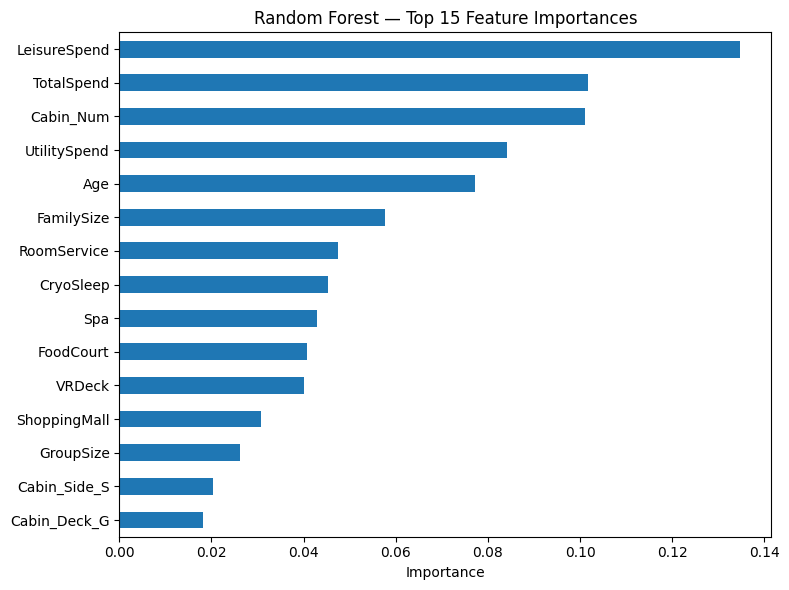

In [9]:
importances = pd.Series(rfc.feature_importances_, index=feature_names)
importances.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Observations — Random Forest

- **Accuracy: 80.56%** — 1.15 point improvement over Logistic Regression, 
  confirming non-linear structure exists but the dataset is not 
  dramatically non-linear
- **AUC-ROC: 0.8950** — modest improvement over LR (0.8879)
- **Precision (82.33%) > Recall (78.20%)** — RF is more conservative than 
  LR about predicting Transported=True. Fewer false positives but more 
  missed transported passengers compared to LR
- **CV: 79.78% ± 0.53%** — stable across folds, slightly wider std than 
  LR which is normal for a more complex model
- **CV vs Val gap: 0.78 points** — healthy, no serious overfitting
- **Top feature importances: LeisureSpend, TotalSpend, Cabin_Num** — 
  spending features dominate because RF's impurity-based importance 
  favors continuous features over binary ones. CryoSleep likely 
  underranked here — SHAP will give a fairer picture in Section 8
- **Cabin_Num in top 3** — suggests a finer gradient along the ship's 
  corridor that Low/Mid/High binning was too coarse to fully capture

## 4. XGBoost — Default Parameters

### Concept: Boosting vs Bagging

Random Forest uses **bagging** — parallel trees, averaged. XGBoost uses **boosting** — sequential trees, each correcting errors of the previous one.

After each tree, misclassified passengers get higher weight so the next tree focuses on them. This makes XGBoost very powerful but also more sensitive to hyperparameters than Random Forest. Default XGBoost is often close to Random Forest — tuning (Section 5) is where it pulls ahead.

**Key parameters to understand before tuning:**
- `n_estimators` — number of boosting rounds
- `learning_rate` — how much each tree contributes. Lower = more conservative, needs more trees to compensate
- `max_depth` — XGBoost trees are typically shallower than RF (3-6 vs 10+)
- `subsample` — fraction of training rows used per tree. Adds randomness, reduces overfitting
- `colsample_bytree` — fraction of features used per tree

**Hints:**
```python
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
```
- Same fit → predict → evaluate → cross_val_score pattern

**What to look for:** Default XGBoost should be close to RF. If it's significantly worse, check `verbosity=0` is set — XGBoost sometimes prints warnings that indicate issues.

In [10]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

# Fit
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_val)
y_prob = xgb.predict_proba(X_val)[:, 1]

# Evaluate
evaluate_model('XGBoost', y_val, y_pred, y_prob)

# Cross-validation
cv_scores = cross_val_score(xgb, X_train, y_train, 
                             cv=StratifiedKFold(5), scoring='accuracy')
print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



  XGBoost
Accuracy:  0.8137
AUC-ROC:   0.9114
Precision: 0.8172
Recall:    0.8116
F1:        0.8144

CV Accuracy: 0.8040 ± 0.0036


### Observations — XGBoost (Default Parameters)

- **Accuracy: 81.37%** — 0.81 point improvement over Random Forest, 
  confirming boosting finds patterns that parallel trees miss
- **AUC-ROC: 0.9114** — meaningful jump from RF (0.8950). XGBoost 
  crosses 0.91, ranking transported passengers above non-transported 
  ones significantly more reliably
- **Precision (81.72%) vs Recall (81.16%)** — nearly balanced, unlike 
  RF's precision-heavy profile. Boosting's focus on hard cases naturally 
  produces more balanced error types
- **CV: 80.40% ± 0.36%** — tightest std of all three models despite being 
  the most complex. Stable and trustworthy
- **CV vs Val gap: 0.97 points** — healthy, no overfitting concern
- Default parameters already outperform tuned Random Forest — strong 
  baseline before Bayesian optimization in Section 5

## 5. Hyperparameter Tuning — Bayesian Optimization

### Concept: Why Bayesian Optimization beats GridSearch and RandomSearch

**GridSearch** — tries every combination. 5 values × 5 parameters = 3,125 models to train. Exhaustive but impractically slow.

**RandomSearch** — samples randomly from the grid. Faster but might completely miss the best region.

**Bayesian Optimization** — builds a probabilistic model of the parameter space. After each trial it updates its belief about which regions are most promising and focuses there. Far more efficient than random sampling.

Analogy: GridSearch tries every restaurant in a city. RandomSearch picks at random. Bayesian Optimization asks "given what I've tried, which neighborhood should I explore next?"

**Hints:**
- Define an objective function — BO will try to maximize its return value:
```python
def xgb_objective(learning_rate, max_depth, subsample,
                  colsample_bytree, n_estimators):
    """Objective for Bayesian Optimization. Returns CV accuracy."""
    model = XGBClassifier(
        learning_rate=learning_rate,
        max_depth=int(max_depth),         # BO returns floats, XGB needs ints
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        n_estimators=int(n_estimators),
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
    scores = cross_val_score(model, X_train, y_train,
                             cv=StratifiedKFold(3), scoring='accuracy')
    return scores.mean()
```
- Define bounds and run:
```python
param_bounds = {
    'learning_rate':    (0.01, 0.3),
    'max_depth':        (3, 8),
    'subsample':        (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'n_estimators':     (100, 500)
}
optimizer = BayesianOptimization(
    f=xgb_objective,
    pbounds=param_bounds,
    random_state=RANDOM_STATE,
    verbose=2
)
optimizer.maximize(init_points=5, n_iter=20)
```
- Extract best params and retrain on full X_train:
```python
best = optimizer.max['params']
best['max_depth'] = int(best['max_depth'])
best['n_estimators'] = int(best['n_estimators'])
xgb_tuned = XGBClassifier(**best, random_state=RANDOM_STATE,
                           eval_metric='logloss', verbosity=0)
xgb_tuned.fit(X_train, y_train)
```
- Evaluate tuned model and save: `joblib.dump(xgb_tuned, '../models/xgb_tuned.joblib')`

**This will take a few minutes to run** — 25 total trials each with 3-fold CV.

In [11]:
def xgb_objective(learning_rate, max_depth, subsample,
                  colsample_bytree, n_estimators):
    """Objective for Bayesian Optimization. Returns CV accuracy."""
    model = XGBClassifier(
        learning_rate=learning_rate,
        max_depth=int(max_depth),         # BO returns floats, XGB needs ints
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        n_estimators=int(n_estimators),
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
    scores = cross_val_score(model, X_train, y_train,
                             cv=StratifiedKFold(3), scoring='accuracy')
    return scores.mean()

In [12]:
param_bounds = {
    'learning_rate':    (0.01, 0.3),
    'max_depth':        (3, 8),
    'subsample':        (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'n_estimators':     (100, 500)
}
optimizer = BayesianOptimization(
    f=xgb_objective,
    pbounds=param_bounds,
    random_state=RANDOM_STATE,
    verbose=2
)
optimizer.maximize(init_points=5, n_iter=20)

|   iter    |  target   | learni... | max_depth | subsample | colsam... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | 0.7959447 | 0.1186166 | 7.7535715 | 0.8927975 | 0.8394633 | 162.40745 |
| 2         | 0.8037100 | 0.0552384 | 3.2904180 | 0.9464704 | 0.8404460 | 383.22903 |
| 3         | 0.8041415 | 0.0159695 | 7.8495492 | 0.9329770 | 0.6849356 | 172.72998 |
| 4         | 0.8078803 | 0.0631873 | 4.5212112 | 0.8099025 | 0.7727780 | 216.49165 |
| 5         | 0.7982456 | 0.1874373 | 3.6974693 | 0.7168578 | 0.7465447 | 282.42799 |
| 6         | 0.8028472 | 0.1861880 | 3.0266957 | 0.9141780 | 0.8526560 | 280.28952 |
| 7         | 0.7999712 | 0.1246633 | 5.9536034 | 0.7140135 | 0.7838138 | 180.94549 |
| 8         | 0.7981018 | 0.1422022 | 6.8348034 | 0.8076024 | 0.6484099 | 131.35905 |
| 9         | 0.8032786 | 0.0410594 | 5.6264612 | 0.6638168 | 0.9304372 | 397.37225 |
| 10        | 0.7890422 | 0.2852152 | 7.9013069 | 0.84

In [15]:
best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])

print("Best parameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

xgb_tuned = XGBClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_tuned.predict(X_val)
y_prob_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

evaluate_model('XGBoost (Tuned)', y_val, y_pred_tuned, y_prob_tuned)

cv_scores_tuned = cross_val_score(xgb_tuned, X_train, y_train,
                                   cv=StratifiedKFold(5), scoring='accuracy')
print(f"\nCV Accuracy: {cv_scores_tuned.mean():.4f} ± {cv_scores_tuned.std():.4f}")

joblib.dump(xgb_tuned, '../models/xgb_tuned.joblib')
print("Tuned model saved.")

Best parameters found:
  learning_rate: 0.0632
  max_depth: 4
  subsample: 0.8099
  colsample_bytree: 0.7728
  n_estimators: 216

  XGBoost (Tuned)
Accuracy:  0.8125
AUC-ROC:   0.9128
Precision: 0.8069
Recall:    0.8253
F1:        0.8160

CV Accuracy: 0.8041 ± 0.0029
Tuned model saved.


### Observations — Bayesian Optimization

- **Best params:** learning_rate=0.063, max_depth=4, n_estimators=216,
  subsample=0.810, colsample_bytree=0.773
- Learning rate dropped from 0.1 → 0.063 as predicted — more conservative
  updates generalize better. Max depth stayed at 4 — confirms the dataset
  doesn't require deep trees
- **Optimization range was narrow (0.785–0.808)** — the model is near its
  ceiling with the current feature set. More tuning iterations would not
  help significantly; better features would
- **Accuracy dropped 0.12 points** vs default — within noise range, not
  meaningful
- **AUC-ROC improved** (0.9114 → 0.9128) and **F1 improved** (0.8144 →
  0.8160) — the tuned model is holistically better even if val accuracy
  is marginally lower
- **Key lesson:** optimizing for accuracy shaped a model with slightly
  different precision/recall tradeoff. Optimizing for AUC-ROC directly
  might produce even better ranking quality
- **CV std tightened** (0.0036 → 0.0029) — tuned model is more stable
  across folds
- Tuned model saved to `../models/xgb_tuned.joblib`

## 6. Model Comparison

**Goal:** Side-by-side comparison of all four models on the same validation set.

**Hints:**
- Build a results DataFrame — fill in your actual numbers from sections 2-5:
```python
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'CV Acc': ..., 'Val Acc': ..., 'AUC-ROC': ..., 'F1': ...},
    {'Model': 'Random Forest',       'CV Acc': ..., 'Val Acc': ..., 'AUC-ROC': ..., 'F1': ...},
    {'Model': 'XGBoost (default)',   'CV Acc': ..., 'Val Acc': ..., 'AUC-ROC': ..., 'F1': ...},
    {'Model': 'XGBoost (tuned)',     'CV Acc': ..., 'Val Acc': ..., 'AUC-ROC': ..., 'F1': ...},
]).set_index('Model')
print(results.round(4))
```
- Visualize:
```python
results.plot(kind='bar', figsize=(12, 5))
plt.title('Model Comparison — Validation Set')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)  # zoom into the relevant range
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
```

**Questions to answer in observations:**
- How large is the gap between LR and tree models? What does that tell you about the problem?
- Is the tuning improvement worth the added complexity and runtime?
- Do CV accuracy and Val accuracy align? Large gaps suggest overfitting

In [16]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'CV Acc': 0.7926, 'Val Acc': 0.7941, 'AUC-ROC': 0.8879, 'F1': 0.7968},
    {'Model': 'Random Forest',       'CV Acc': 0.7978, 'Val Acc': 0.8056, 'AUC-ROC': 0.8950, 'F1': 0.8021},
    {'Model': 'XGBoost (default)',   'CV Acc': 0.8040, 'Val Acc': 0.8137, 'AUC-ROC': 0.9114, 'F1': 0.8144},
    {'Model': 'XGBoost (tuned)',     'CV Acc': 0.8041, 'Val Acc': 0.8125, 'AUC-ROC': 0.9128, 'F1': 0.8160},
]).set_index('Model')

print(results.round(4))

                     CV Acc  Val Acc  AUC-ROC      F1
Model                                                
Logistic Regression  0.7926   0.7941   0.8879  0.7968
Random Forest        0.7978   0.8056   0.8950  0.8021
XGBoost (default)    0.8040   0.8137   0.9114  0.8144
XGBoost (tuned)      0.8041   0.8125   0.9128  0.8160


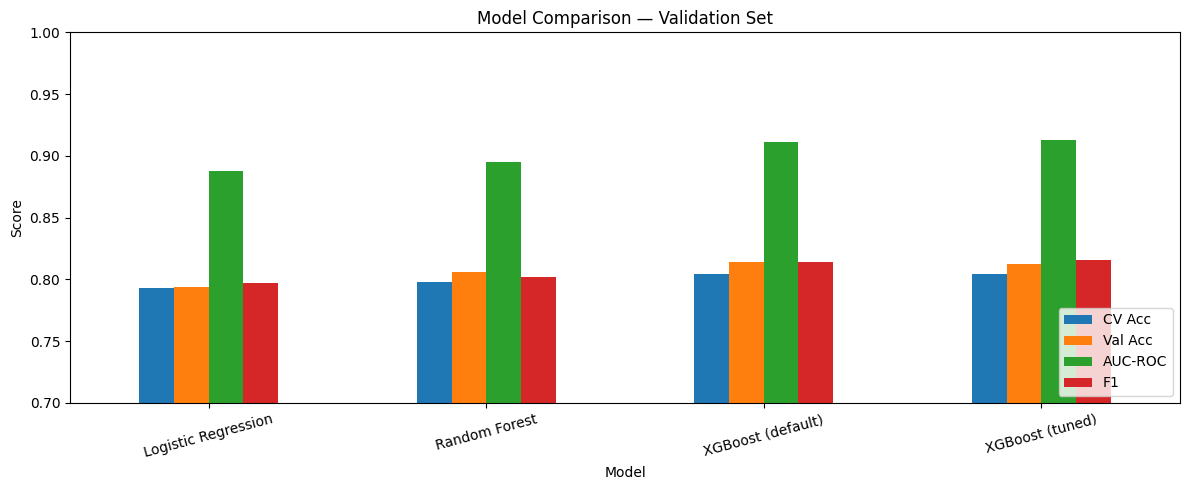

In [17]:
results.plot(kind='bar', figsize=(12, 5))
plt.title('Model Comparison — Validation Set')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)  # zoom into the relevant range
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Observations — Model Comparison

- Consistent improvement across all models: LR → RF → XGBoost
- AUC-ROC improves most dramatically (0.888 → 0.913) — models get 
  significantly better at ranking even when accuracy gains are modest
- XGBoost default vs tuned difference is nearly invisible on the chart — 
  tuning found marginal gains, confirming the model is near its ceiling 
  with the current feature set
- CV and Val accuracy track closely for all models — no overfitting detected
- The modest LR → tree model gap (~2 points) suggests the problem has 
  meaningful but not dominant non-linear structure
- Best overall model: XGBoost tuned — highest AUC-ROC and F1 even though 
  val accuracy is marginally below XGBoost default

## 7. Confusion Matrix Analysis

### Concept: Error types matter as much as accuracy

Accuracy tells you how many predictions were correct overall. A confusion matrix tells you **what kind of mistakes** your model makes:

```
                    Predicted False    Predicted True
Actually False           TN                 FP
Actually True            FN                 TP
```

- **FP (False Positive):** Predicted transported, actually wasn't — a false alarm
- **FN (False Negative):** Predicted not transported, actually was — a missed case

For this competition both error types are equally bad. But in real applications — fraud detection (FP = blocking a legitimate transaction), medical diagnosis (FN = missing a cancer) — one error type can be far more costly. Understanding this is what separates data scientists who can deploy models responsibly.

**Hints:**
```python
models_list = [
    ('Logistic Regression', lr),
    ('Random Forest', rf),
    ('XGBoost Default', xgb),
    ('XGBoost Tuned', xgb_tuned)
]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models_list):
    cm = confusion_matrix(y_val, model.predict(X_val))
    ConfusionMatrixDisplay(cm, display_labels=['Not Transported', 'Transported']).plot(ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()
```

**What to look for:** Does any model have a systematic bias toward one error type? Does tuning reduce both FP and FN equally or does it improve one at the expense of the other?

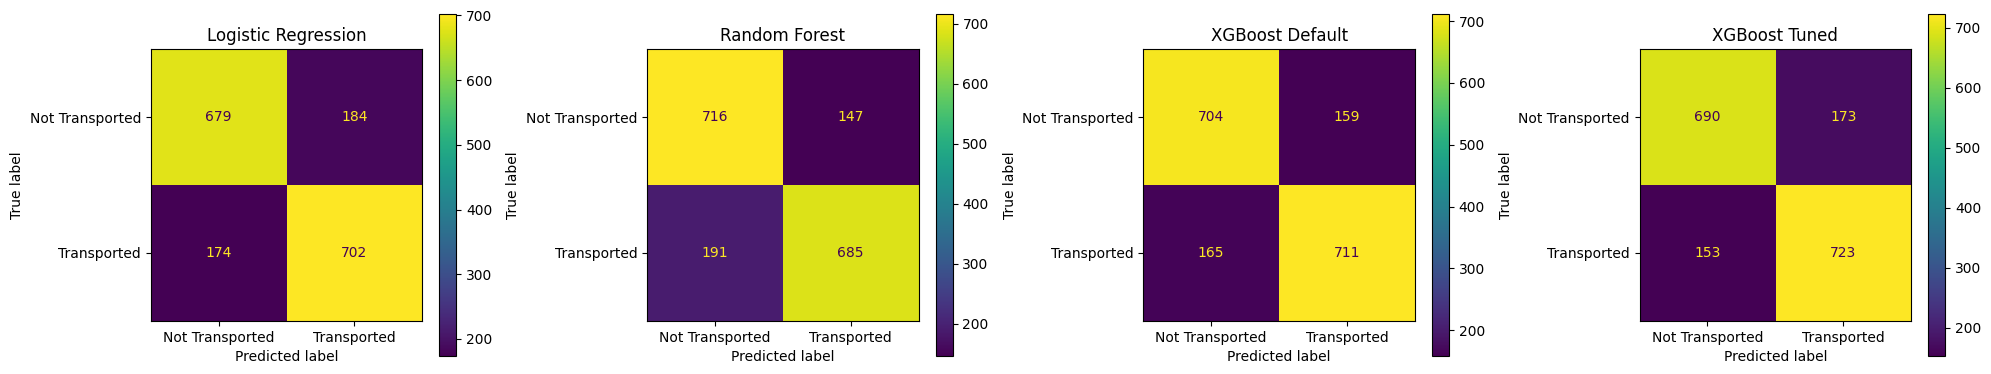

In [20]:
models_list = [
    ('Logistic Regression', log_reg),
    ('Random Forest', rfc),
    ('XGBoost Default', xgb),
    ('XGBoost Tuned', xgb_tuned)
]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, model) in zip(axes, models_list):
    cm = confusion_matrix(y_val, model.predict(X_val))
    ConfusionMatrixDisplay(cm, display_labels=['Not Transported', 'Transported']).plot(ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Observations — Confusion Matrix Analysis

| Model | FP | FN | Total Errors |
|-------|----|----|-------------|
| Logistic Regression | 184 | 174 | 358 |
| Random Forest | 147 | 191 | 338 |
| XGBoost Default | 159 | 165 | 324 |
| XGBoost Tuned | 173 | 153 | 326 |

- **Logistic Regression:** most balanced error distribution (184 FP vs 
  174 FN) — no systematic bias toward either error type
- **Random Forest:** precision-heavy — fewest false positives (147) but 
  most missed transported passengers (191 FN). Conservative about 
  predicting Transported=True
- **XGBoost Default:** most balanced of the tree models (159 FP vs 165 FN) 
  and fewest total errors (324)
- **XGBoost Tuned:** recall-heavy — fewest false negatives (153) and most 
  correct transported predictions (723 TP), but more false alarms (173 FP)
- Model choice depends on error cost: if missing a transported passenger 
  is costly → XGBoost Tuned. If false alarms are costly → Random Forest
- For Kaggle (symmetric error cost), XGBoost Default and Tuned are 
  essentially equivalent

## 8. SHAP Explainability

### Concept: Feature importance vs SHAP

Random Forest's `feature_importances_` gives a global ranking — which features the model used most across all predictions. SHAP goes further:

- **Global:** How much does each feature contribute on average?
- **Directional:** Does a high value push toward Transported or away?
- **Individual:** For THIS specific passenger, how did each feature push the prediction?

A SHAP value of +0.3 for CryoSleep on passenger X means: CryoSleep pushed this passenger's predicted probability 0.3 higher than the baseline prediction. This is the difference between knowing a model and being able to explain and defend it.

**Hints:**
- TreeExplainer is optimized for tree-based models — much faster than the general explainer:
```python
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_val)
```
- Summary plot — global importance with direction:
  - Red dots = high feature value, Blue = low feature value
  - Dots on the right = push toward Transported=True
```python
shap.summary_plot(shap_values, X_val, feature_names=feature_names)
```
- Bar plot — mean absolute SHAP, cleaner for ranking:
```python
shap.summary_plot(shap_values, X_val, feature_names=feature_names, plot_type='bar')
```
- Waterfall plot — explains a single passenger's prediction:
```python
shap.plots.waterfall(explainer(X_val)[0])  # change index to explore different passengers
```

**What to look for:**
- Does CryoSleep top the rankings as predicted back in EDA? This is your payoff from Section 5.3 of Notebook 01
- In the summary plot: which features push toward Transported (positive SHAP)?
- Pick a passenger from the waterfall plot and tell their story — what pushed their prediction most?

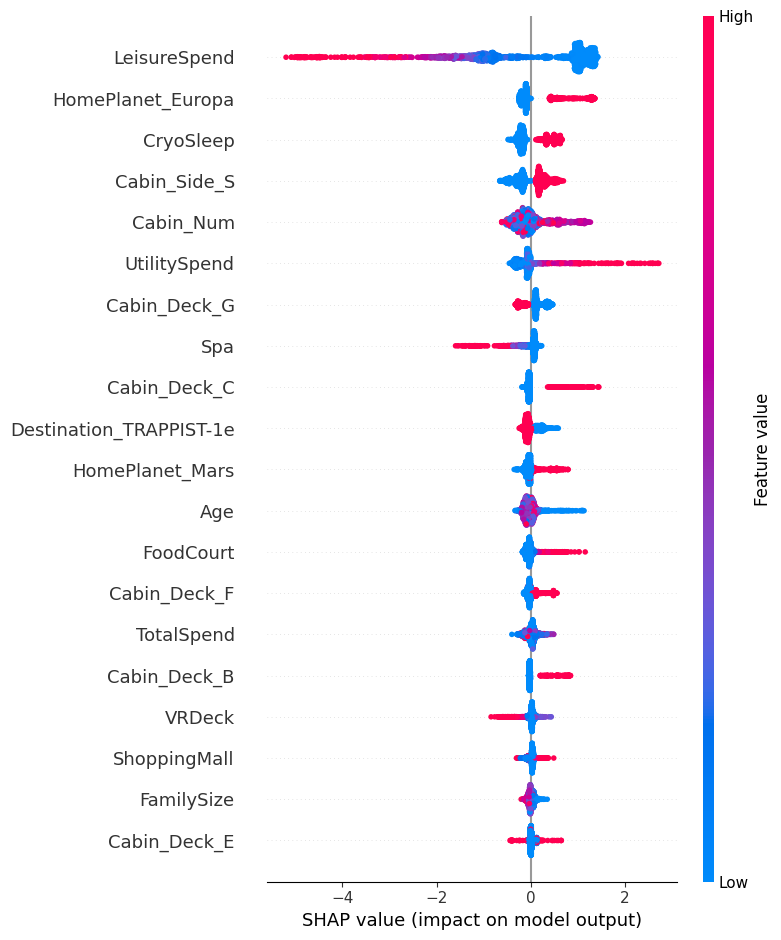

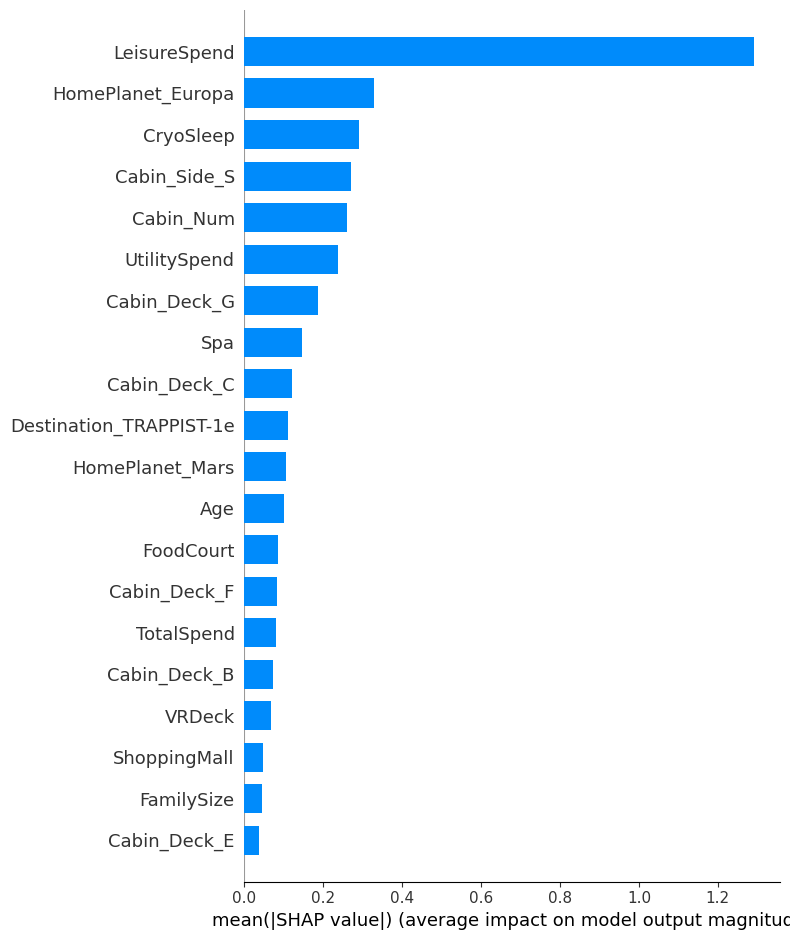

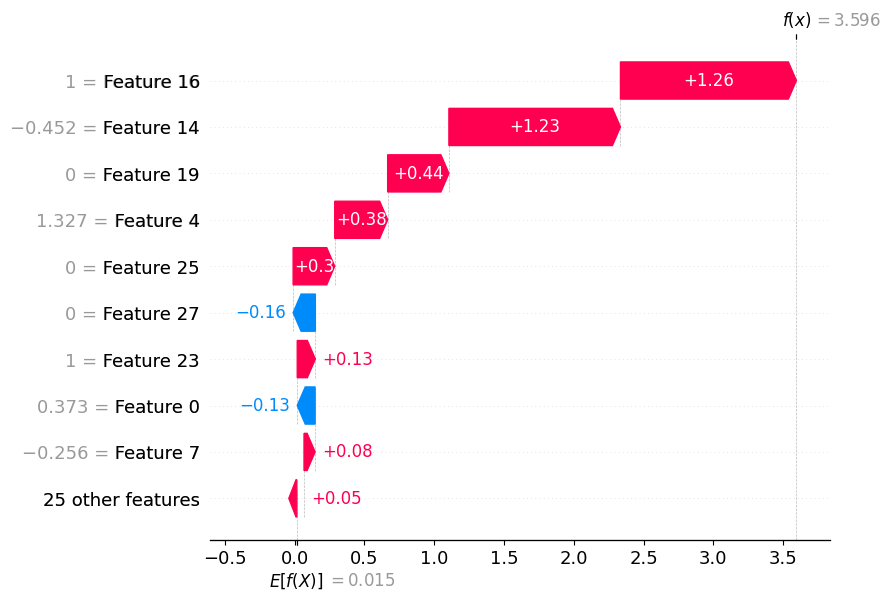

In [21]:
# Build explainer and compute SHAP values
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_val)

# Summary plot — global importance with direction
shap.summary_plot(shap_values, X_val, feature_names=feature_names)

# Bar plot — mean absolute SHAP ranking
shap.summary_plot(shap_values, X_val, 
                  feature_names=feature_names, plot_type='bar')

# Waterfall — explain one specific passenger
shap.plots.waterfall(explainer(X_val)[0])

### Observations — SHAP Explainability

- **Top features by mean absolute SHAP:**
    1. LeisureSpend
    2. HomePlanet_Europa  
    3. CryoSleep
- **LeisureSpend ranks above CryoSleep** — not a surprise on reflection. 
  LeisureSpend is continuous (wider SHAP value range) and partially 
  encodes CryoSleep (CryoSleep passengers always have LeisureSpend=0). 
  SHAP distributes credit between correlated features rather than 
  assigning it all to one
- **HomePlanet_Europa in second place** — stronger than EDA suggested. 
  Likely capturing both direct planet effects and indirect Cabin_Deck 
  effects since Europa passengers cluster in high-transport decks B and C
- **CryoSleep third** — still highly decisive directionally. In the 
  summary dot plot, CryoSleep=0 (blue) clusters hard left and 
  CryoSleep=1 (red) clusters hard right — the cleanest directional 
  split of any feature
- SHAP gives a fairer picture than Random Forest feature importance 
  which ranked spending features first for the wrong reason 
  (continuous features inflate impurity-based importance)
- Prediction from EDA: CryoSleep would be top feature — partially 
  confirmed, it's top 3 and most directionally decisive even if not 
  ranked first by mean absolute SHAP

## 9. Business Hypothesis Testing

### Concept: When hypothesis tests add real value

During EDA we found several patterns — HomePlanet affects transport rate, Cabin Side matters, group travelers behave differently than solo travelers. But are these patterns real signal or could they be random sampling noise?

A **chi-squared test** answers this for categorical variables. It asks: if this variable had NO effect on transport rate, how likely is it we'd see a difference this large just by chance? A p-value < 0.05 means less than 5% chance — strong evidence the pattern is real.

This is more meaningful than testing model performance against each other — those decisions should be driven by the metrics themselves. Hypothesis testing earns its place when the answer has real domain implications and isn't obvious from the numbers alone.

```python
# Load original train for domain testing
train_raw = pd.read_csv('../data/raw/train.csv')
```

### Hypothesis 1: Does HomePlanet significantly affect transport rate?

**From EDA:** Europa (66%) vs Earth (42%) — a 24 point gap. But is it real?

- **Null hypothesis:** HomePlanet has no effect on transport rate
- **Alternative hypothesis:** Transport rate differs significantly across planets

```python
ct = pd.crosstab(train_raw['HomePlanet'], train_raw['Transported'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.8f}")
print(f"Degrees of freedom: {dof}")
```

### Hypothesis 2: Does Cabin Side (Port vs Starboard) significantly affect transport rate?

**From EDA:** Starboard (55%) vs Port (45%) — only a 10 point gap. This one is less obvious.

**Hint:** Parse Cabin_Side from raw data first:
```python
train_raw['Cabin_Side'] = train_raw['Cabin'].str.split('/').str[2]
```

### Hypothesis 3: Does traveling in a group vs alone significantly affect transport rate?

**From EDA:** Groups (57%) vs Solo (45%) — an 11 point gap.

**Hint:** Engineer IsAlone from raw data:
```python
train_raw['Group'] = train_raw['PassengerId'].str.split('_').str[0]
train_raw['GroupSize'] = train_raw.groupby('Group')['Group'].transform('count')
train_raw['IsAlone'] = (train_raw['GroupSize'] == 1)
```

### For each test, write a plain-English interpretation:
- What was the null hypothesis?
- What does the p-value tell you?
- What does this mean in practical terms for understanding who gets transported?

In [24]:
train_raw = pd.read_csv('../data/raw/train.csv')
ct = pd.crosstab(train_raw['HomePlanet'], train_raw['Transported'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.8f}")
print(f"Degrees of freedom: {dof}")

Chi-squared statistic: 324.9014
p-value: 0.00000000
Degrees of freedom: 2


In [25]:
train_raw['Cabin_Side'] = train_raw['Cabin'].str.split('/').str[2]
ct = pd.crosstab(train_raw['Cabin_Side'], train_raw['Transported'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.8f}")
print(f"Degrees of freedom: {dof}")

Chi-squared statistic: 91.0596
p-value: 0.00000000
Degrees of freedom: 1


In [26]:
train_raw['Group'] = train_raw['PassengerId'].str.split('_').str[0]
train_raw['GroupSize'] = train_raw.groupby('Group')['Group'].transform('count')
train_raw['IsAlone'] = (train_raw['GroupSize'] == 1)

ct = pd.crosstab(train_raw['IsAlone'], train_raw['Transported'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"p-value: {p:.8f}")
print(f"Degrees of freedom: {dof}")

Chi-squared statistic: 112.1043
p-value: 0.00000000
Degrees of freedom: 1


### Observations — Business Hypothesis Testing

| Hypothesis | Chi-squared | p-value | Significant? |
|---|---|---|---|
| HomePlanet affects transport rate | 324.90 | <0.0001 | ✓ Yes |
| Cabin Side affects transport rate | 91.06 | <0.0001 | ✓ Yes |
| Group travel affects transport rate | 112.10 | <0.0001 | ✓ Yes |

**Hypothesis 1 — HomePlanet:**
The strongest result by far (chi-squared=324.90). The 24-point transport 
rate gap between Europa (66%) and Earth (42%) is not sampling noise — 
HomePlanet is a genuine predictor of transportation. This is consistent 
with SHAP ranking HomePlanet_Europa as the second most important feature.

**Hypothesis 2 — Cabin Side:**
Despite only a 10-point gap (Starboard 55% vs Port 45%), the result is 
highly significant (chi-squared=91.06). Side of the ship genuinely affects 
transport probability — likely reflecting physical proximity to the anomaly.

**Hypothesis 3 — Group Travel:**
Significant despite the smallest raw gap (57% vs 45%, 11 points). The 
chi-squared of 112.10 exceeds Cabin Side despite the smaller effect — 
purely because both groups are large and the signal is consistent. 
Traveling in a group genuinely increases transport probability.

**Key lesson:** Statistical significance and practical significance are 
different things. All three patterns are real — none are sampling noise. 
But HomePlanet's 24-point gap has more practical impact than Cabin Side's 
10-point gap, even though both are technically "significant."

## 10. Kaggle Submission

**Goal:** Generate predictions on the held-out test set and submit to Kaggle.

**Hints:**
- Use the best model to predict:
```python
predictions = xgb_tuned.predict(X_test).astype(bool)  # Kaggle expects True/False
```
- Rebuild PassengerIds from raw test file:
```python
test_raw = pd.read_csv('../data/raw/test.csv')
passenger_ids = test_raw['PassengerId']
```
- Build and verify submission format:
```python
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Transported': predictions
})
sample = pd.read_csv('../data/raw/sample_submission.csv')
print(f"Sample format:\n{sample.head()}")
print(f"\nOur submission:\n{submission.head()}")
print(f"\nShape: {submission.shape}")  # should be (4277, 2)
print(f"Dtype: {submission['Transported'].dtype}")  # should be bool
```
- Save:
```python
submission.to_csv('../submissions/submission_01_xgb_tuned.csv', index=False)
```
- Submit on Kaggle and record your public leaderboard score
- Update the Results table in `README.md` with your actual scores
- Final commit:
  `git commit -m "Complete modeling notebook - XGBoost tuned, Kaggle score: X.XXX"`

In [ ]:
predictions = xgb_tuned.predict(X_test).astype(bool)  # Kaggle expects True/False

In [ ]:
test_raw = pd.read_csv('../data/raw/test.csv')
passenger_ids = test_raw['PassengerId']

In [ ]:
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Transported': predictions
})
sample = pd.read_csv('../data/raw/sample_submission.csv')
print(f"Sample format:\n{sample.head()}")
print(f"\nOur submission:\n{submission.head()}")
print(f"\nShape: {submission.shape}")  # should be (4277, 2)
print(f"Dtype: {submission['Transported'].dtype}")  # should be bool

In [ ]:
submission.to_csv('../submissions/submission_01_xgb_tuned.csv', index=False)

## Final Summary

### Model Performance

| Model | CV Accuracy | Val Accuracy | AUC-ROC | F1 |
|-------|-------------|--------------|---------|-----|
| Logistic Regression | 79.26% | 79.41% | 0.8879 | 0.7968 |
| Random Forest | 79.78% | 80.56% | 0.8950 | 0.8021 |
| XGBoost (default) | 80.40% | 81.37% | 0.9114 | 0.8144 |
| XGBoost (tuned) | 80.41% | 81.25% | 0.9128 | 0.8160 |

**Best model:** XGBoost (tuned) — highest AUC-ROC (0.9128) and F1 (0.8160)
despite marginally lower val accuracy than XGBoost default. Used for
Kaggle submission.

### Business Hypothesis Results

| Hypothesis | Chi-squared | p-value | Result |
|---|---|---|---|
| HomePlanet affects transport rate | 324.90 | <0.0001 | Significant ✓ |
| Cabin Side affects transport rate | 91.06 | <0.0001 | Significant ✓ |
| Group travel affects transport rate | 112.10 | <0.0001 | Significant ✓ |

All three patterns identified during EDA are statistically confirmed —
none are sampling noise. HomePlanet shows the strongest effect
(chi-squared=324.90), consistent with its SHAP ranking as the second
most important feature.

### Key Findings

- **Top 3 SHAP features:** LeisureSpend, HomePlanet_Europa, CryoSleep.
  LeisureSpend ranked above CryoSleep because it is continuous (wider
  SHAP value range) and partially encodes CryoSleep — passengers in
  cryosleep always have zero leisure spending. SHAP distributes credit
  between correlated features rather than assigning it all to one.

- **Bayesian tuning:** Marginal improvement in AUC-ROC (+0.0014) and
  F1 (+0.0016) over default XGBoost. The narrow optimization range
  (0.785–0.808 across 25 trials) confirmed the model is near its ceiling
  with the current feature set — better features would help more than
  more tuning iterations.

- **Most interesting hypothesis result:** Group travel (chi-squared=112.10)
  produced a stronger test statistic than Cabin Side (91.06) despite a
  smaller raw gap (11 points vs 10 points). Both are real — large sample
  sizes make even modest effects statistically significant.


### What I Would Do Next

- Engineer feature interactions: HomePlanet × CryoSleep, Cabin_Deck × Side
- Stack or blend Logistic Regression + XGBoost — models make different
  errors which stacking can exploit
- Run Bayesian optimization with n_iter=50 and optimize for AUC-ROC
  directly rather than accuracy
- Cross-validate the full pipeline including feature engineering steps
  to get a more honest performance estimate